In [2]:
#Import main libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Read csv files
features_df = pd.read_csv('features_data_set.csv')
sales_df = pd.read_csv('sales_data_set.csv')
stores_df = pd.read_csv('stores_data_set.csv')

In [4]:
#Explore the files data
features_df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [5]:
sales_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [6]:
stores_df.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [7]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [8]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [9]:
stores_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [ ]:
#Standarize the column headers
features_df.columns = features_df.columns.str.lower().str.replace(' ', '_')
sales_df.columns = sales_df.columns.str.lower().str.replace(' ', '_')
stores_df.columns = stores_df.columns.str.lower().str.replace(' ', '_')
sales_df.head()


,store,dept,date,weekly_sales,isholiday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [11]:
sales_df['date'] = pd.to_datetime(sales_df['date'], format= '%d/%m/%Y')
features_df['date'] = pd.to_datetime(features_df['date'], format= '%d/%m/%Y')
sales_df.info()
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   store         421570 non-null  int64         
 1   dept          421570 non-null  int64         
 2   date          421570 non-null  datetime64[ns]
 3   weekly_sales  421570 non-null  float64       
 4   isholiday     421570 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2)
memory usage: 13.3 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   store         8190 non-null   int64         
 1   date          8190 non-null   datetime64[ns]
 2   temperature   8190 non-null   float64       
 3   fuel_price    8190 non-null   float64       
 4   markdown1     4032 non-null   float64     

In [12]:
#Markdown columns are promotions. We will replace NaN with 0
features_df[['markdown1', 'markdown2', 'markdown3', 'markdown4', 'markdown5']] = features_df[['markdown1', 'markdown2', 'markdown3', 'markdown4', 'markdown5']].fillna(0)
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   store         8190 non-null   int64         
 1   date          8190 non-null   datetime64[ns]
 2   temperature   8190 non-null   float64       
 3   fuel_price    8190 non-null   float64       
 4   markdown1     8190 non-null   float64       
 5   markdown2     8190 non-null   float64       
 6   markdown3     8190 non-null   float64       
 7   markdown4     8190 non-null   float64       
 8   markdown5     8190 non-null   float64       
 9   cpi           7605 non-null   float64       
 10  unemployment  7605 non-null   float64       
 11  isholiday     8190 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float64(9), int64(1)
memory usage: 712.0 KB


In [13]:
#For unemployment and cpi columns we will replace NaN values with a linear interpolation of values.
features_df['cpi'] = features_df['cpi'].interpolate(method='linear')
features_df['unemployment'] = features_df['unemployment'].interpolate(method='linear')
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   store         8190 non-null   int64         
 1   date          8190 non-null   datetime64[ns]
 2   temperature   8190 non-null   float64       
 3   fuel_price    8190 non-null   float64       
 4   markdown1     8190 non-null   float64       
 5   markdown2     8190 non-null   float64       
 6   markdown3     8190 non-null   float64       
 7   markdown4     8190 non-null   float64       
 8   markdown5     8190 non-null   float64       
 9   cpi           8190 non-null   float64       
 10  unemployment  8190 non-null   float64       
 11  isholiday     8190 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float64(9), int64(1)
memory usage: 712.0 KB


In [14]:
#Let's create our master DF by merging the tables. 
sales_stores_df = sales_df.merge(stores_df, how='left', on='store')
sales_stores_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   store         421570 non-null  int64         
 1   dept          421570 non-null  int64         
 2   date          421570 non-null  datetime64[ns]
 3   weekly_sales  421570 non-null  float64       
 4   isholiday     421570 non-null  bool          
 5   type          421570 non-null  object        
 6   size          421570 non-null  int64         
dtypes: bool(1), datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 19.7+ MB


In [15]:
retail_df = sales_stores_df.merge(features_df, how='left', on=['store', 'date', 'isholiday'])
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   store         421570 non-null  int64         
 1   dept          421570 non-null  int64         
 2   date          421570 non-null  datetime64[ns]
 3   weekly_sales  421570 non-null  float64       
 4   isholiday     421570 non-null  bool          
 5   type          421570 non-null  object        
 6   size          421570 non-null  int64         
 7   temperature   421570 non-null  float64       
 8   fuel_price    421570 non-null  float64       
 9   markdown1     421570 non-null  float64       
 10  markdown2     421570 non-null  float64       
 11  markdown3     421570 non-null  float64       
 12  markdown4     421570 non-null  float64       
 13  markdown5     421570 non-null  float64       
 14  cpi           421570 non-null  float64       
 15  unemployment  421

In [16]:
retail_df.to_csv('retail_data.csv', index=False)

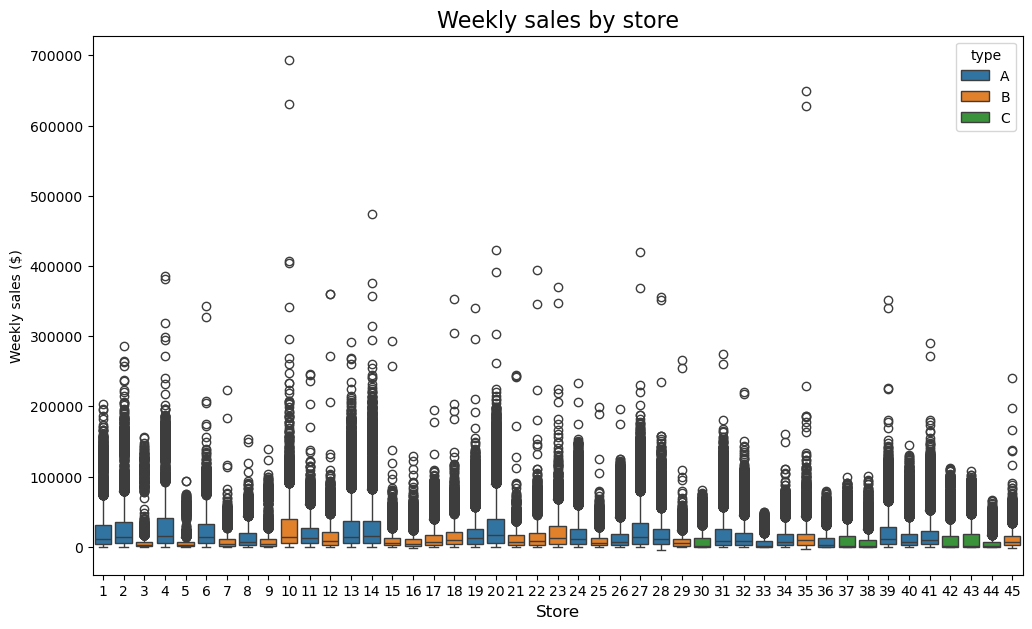

In [17]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=retail_df, x='store', y='weekly_sales', hue='type', whis=1.5)
plt.title('Weekly sales by store', fontsize=16)
plt.xlabel('Store', fontsize=12)
plt.ylabel('Weekly sales ($)')
plt.show()

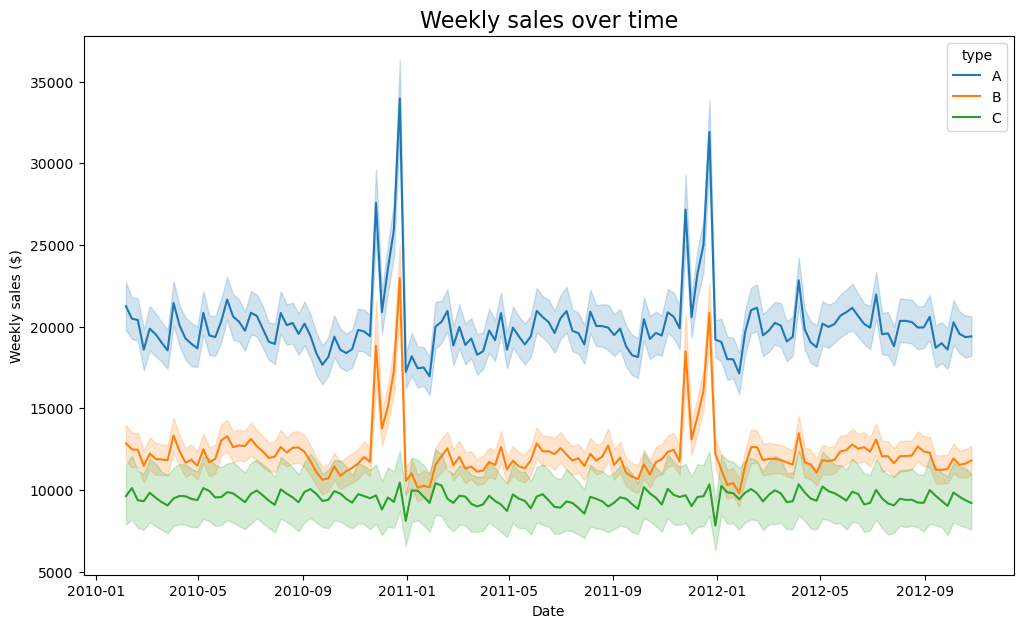

In [18]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=retail_df, x='date', y='weekly_sales', hue='type')
plt.title('Weekly sales over time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Weekly sales ($)')
plt.show()

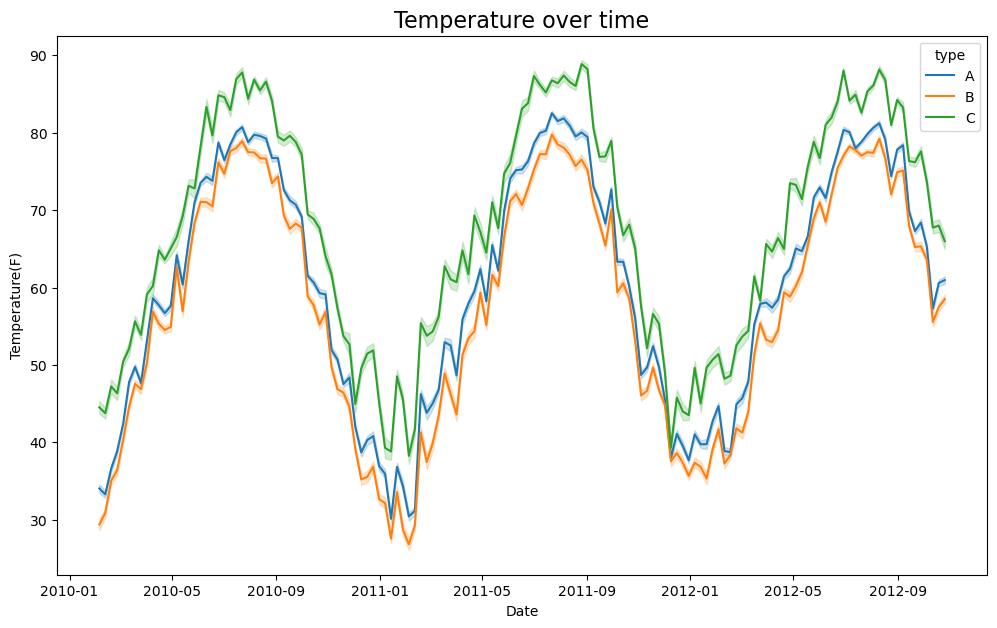

In [19]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=retail_df, x='date', y='temperature', hue='type')
plt.title('Temperature over time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Temperature(F)')
plt.show()

In [20]:
retail_df.describe()

,store,dept,date,weekly_sales,size,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,136727.915739,60.090059,3.361027,2590.074819,879.974298,468.087665,1083.132268,1662.772385,171.201947,7.960289
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,34875.000000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,93638.000000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,140167.000000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.318780,7.866000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,202505.000000,74.280000,3.738000,2809.050000,2.200000,4.540000,425.290000,2168.040000,212.416993,8.572000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,219622.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000
std,12.785297,30.492054,NaN,22711.183519,60980.583328,18.447931,0.458515,6052.385934,5084.538801,5528.873453,3894.529945,4207.629321,39.159276,1.863296


In [21]:
negative_sales = (retail_df['weekly_sales'] < 0).sum()
print('Negative sales weeks:', negative_sales)

Negative sales weeks: 1285


c:\Users\aldox\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


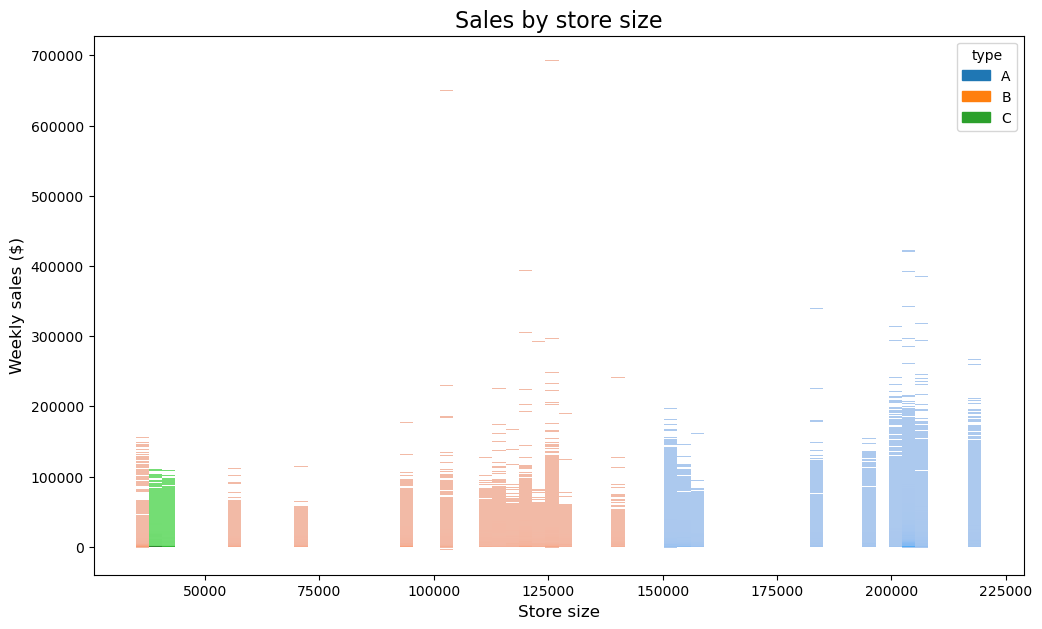

In [22]:
plt.figure(figsize=(12, 7))
sns.histplot(data=retail_df, x='size', y='weekly_sales', hue='type')
plt.title('Sales by store size', fontsize=16)
plt.xlabel('Store size', fontsize=12)
plt.ylabel('Weekly sales ($)', fontsize=12)
plt.show()

In [23]:
retail_df['store'] = retail_df['store'].astype('object')

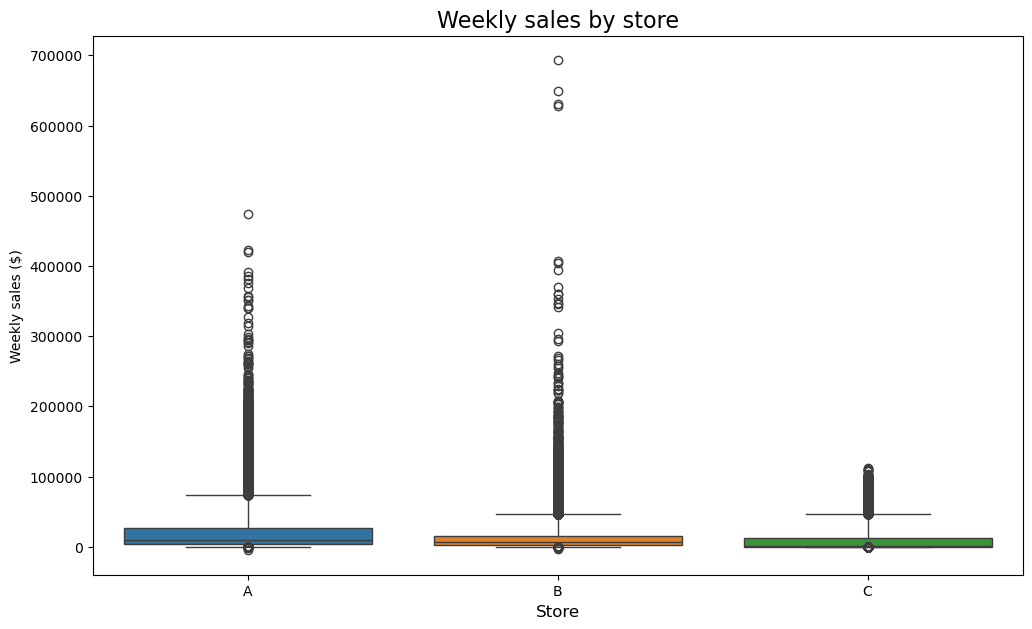

In [24]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=retail_df, x='type', y='weekly_sales', hue='type', whis=(5, 95))
plt.title('Weekly sales by store', fontsize=16)
plt.xlabel('Store', fontsize=12)
plt.ylabel('Weekly sales ($)')
plt.show()

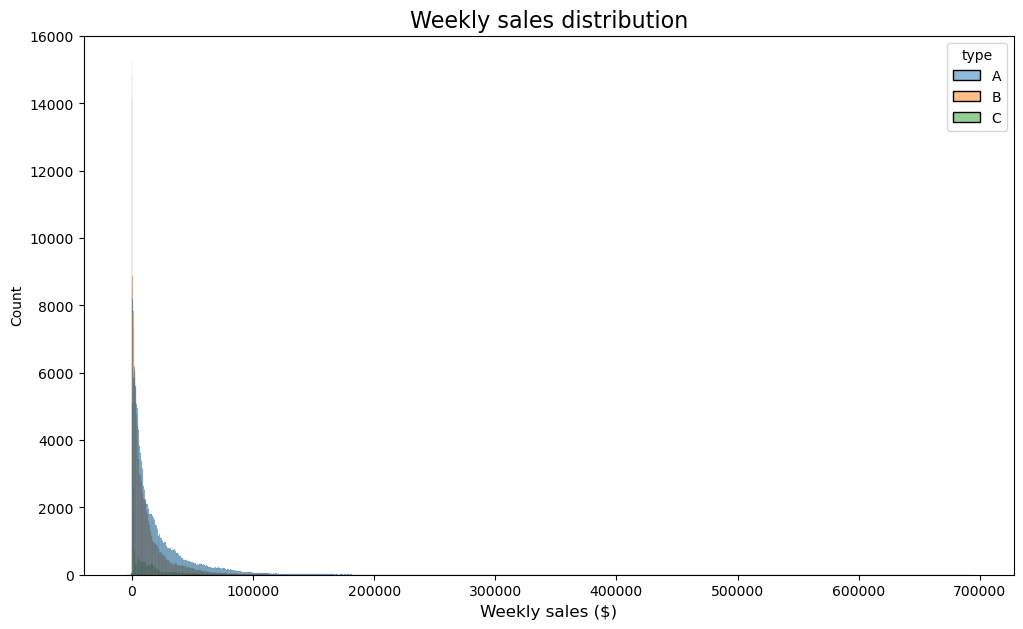

In [25]:
plt.figure(figsize=(12, 7))
sns.histplot(data= retail_df, x='weekly_sales', hue='type')
plt.title('Weekly sales distribution', fontsize= 16)
plt.xlabel('Weekly sales ($)', fontsize= 12)
plt.show()

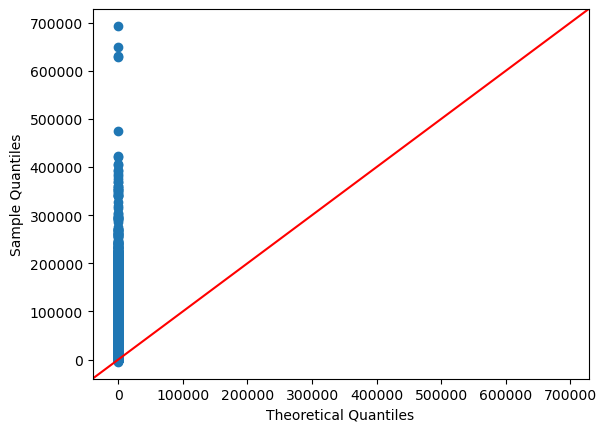

In [26]:
import statsmodels.api as sm
import pylab as py
weekly_sales = retail_df['weekly_sales']
sm.qqplot(weekly_sales, line = '45')
py.show()



c:\Users\aldox\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\aldox\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


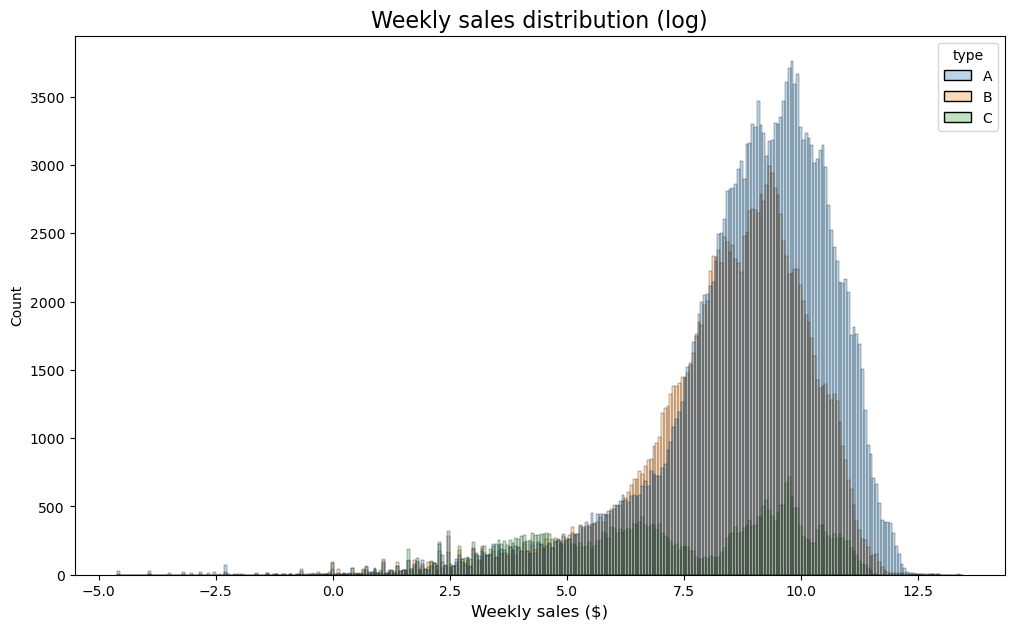

In [27]:
retail_df['weekly_sales_log'] = np.log(retail_df['weekly_sales'])
plt.figure(figsize=(12, 7))
sns.histplot(data= retail_df, x='weekly_sales_log', hue='type', alpha= 0.3)
plt.title('Weekly sales distribution (log)', fontsize= 16)
plt.xlabel('Weekly sales ($)', fontsize= 12)
plt.show()

In [28]:
avg_sales_by_type = retail_df.groupby('type')['weekly_sales'].mean()
print(avg_sales_by_type)

type
A    20099.568043
B    12237.075977
C     9519.532538
Name: weekly_sales, dtype: float64


In [29]:
max_sales_by_type = retail_df.groupby('type')['weekly_sales'].max()
min_sales_by_type = retail_df.groupby('type')['weekly_sales'].min()
print('Max sales by store type:', max_sales_by_type)
print('Min sales by store type:', min_sales_by_type)

Max sales by store type: type
A    474330.10
B    693099.36
C    112152.35
Name: weekly_sales, dtype: float64
Min sales by store type: type
A   -4988.94
B   -3924.00
C    -379.00
Name: weekly_sales, dtype: float64


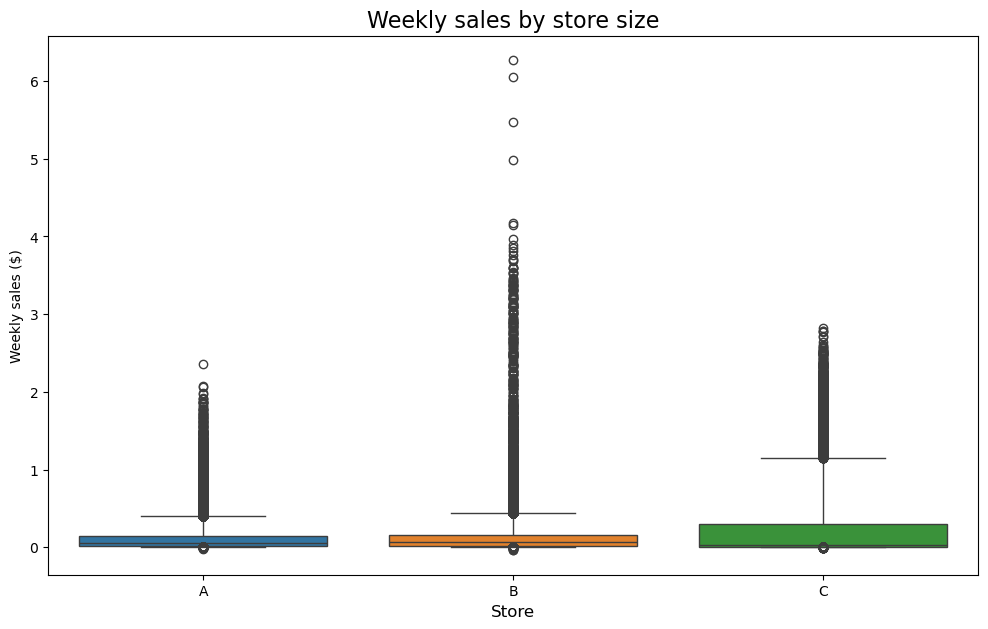

In [30]:
retail_df['weekly_sales_by_size'] = retail_df['weekly_sales']/retail_df['size']
plt.figure(figsize=(12, 7))
sns.boxplot(data=retail_df, x='type', y='weekly_sales_by_size', hue='type', whis=(5, 95))
plt.title('Weekly sales by store size', fontsize=16)
plt.xlabel('Store', fontsize=12)
plt.ylabel('Weekly sales ($)')
plt.show()

In [31]:
avg_sales_by_type_size = retail_df.groupby('type')['weekly_sales_by_size'].mean()
median_sales_by_type_size = retail_df.groupby('type')['weekly_sales_by_size'].median()

In [32]:
print(avg_sales_by_type_size)
print(median_sales_by_type_size)

type
A    0.112971
B    0.124119
C    0.234828
Name: weekly_sales_by_size, dtype: float64
type
A    0.056385
B    0.065833
C    0.028389
Name: weekly_sales_by_size, dtype: float64


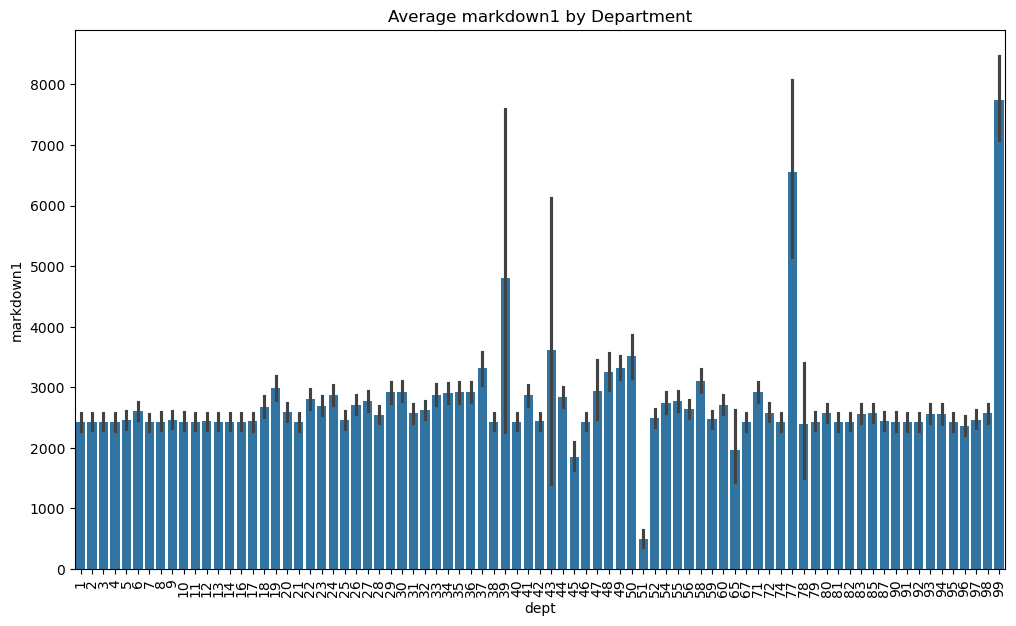

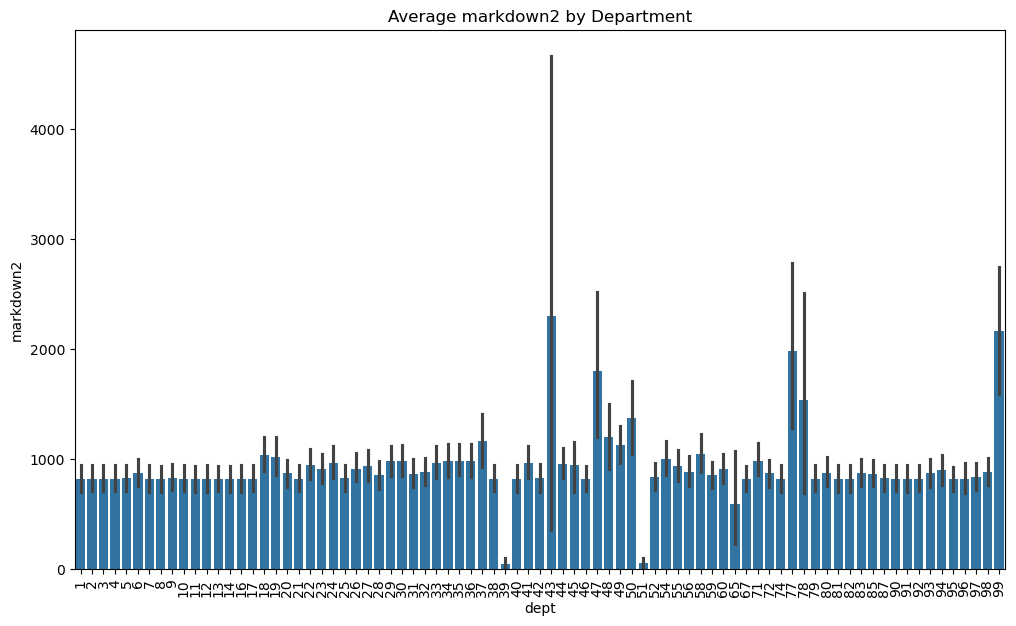

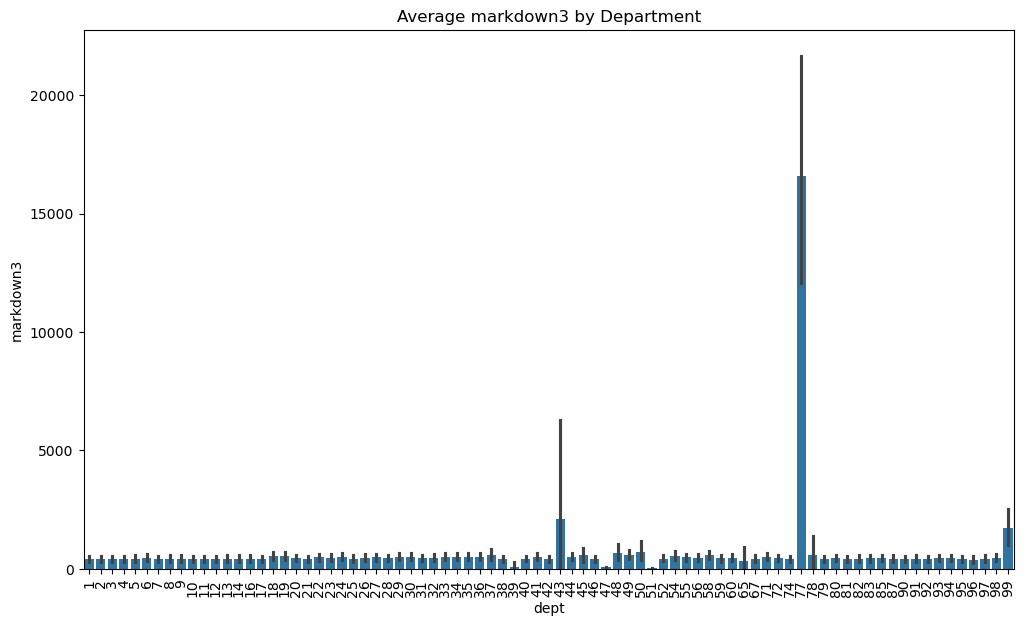

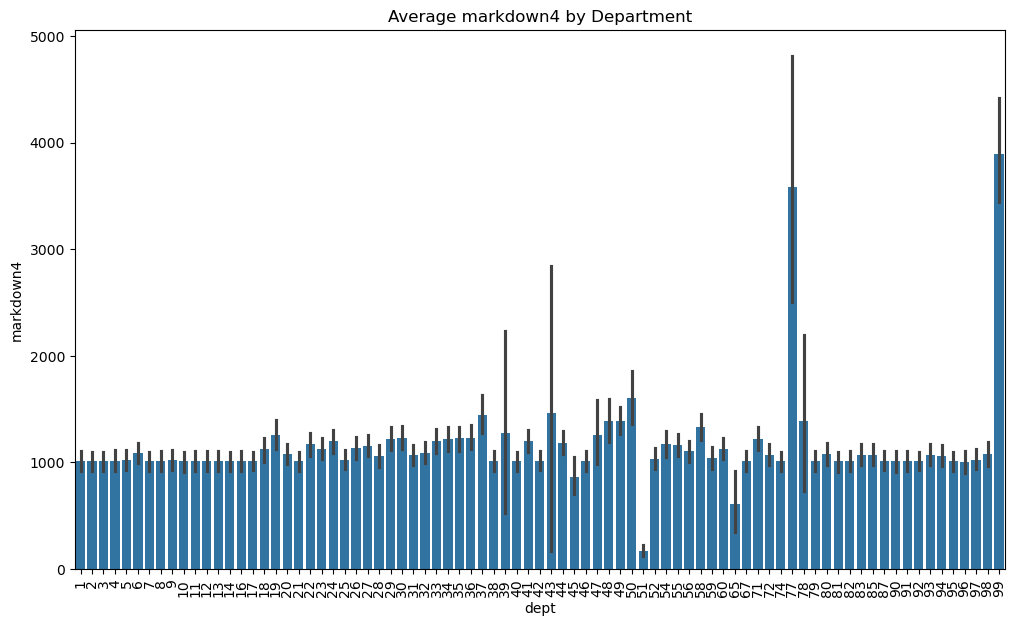

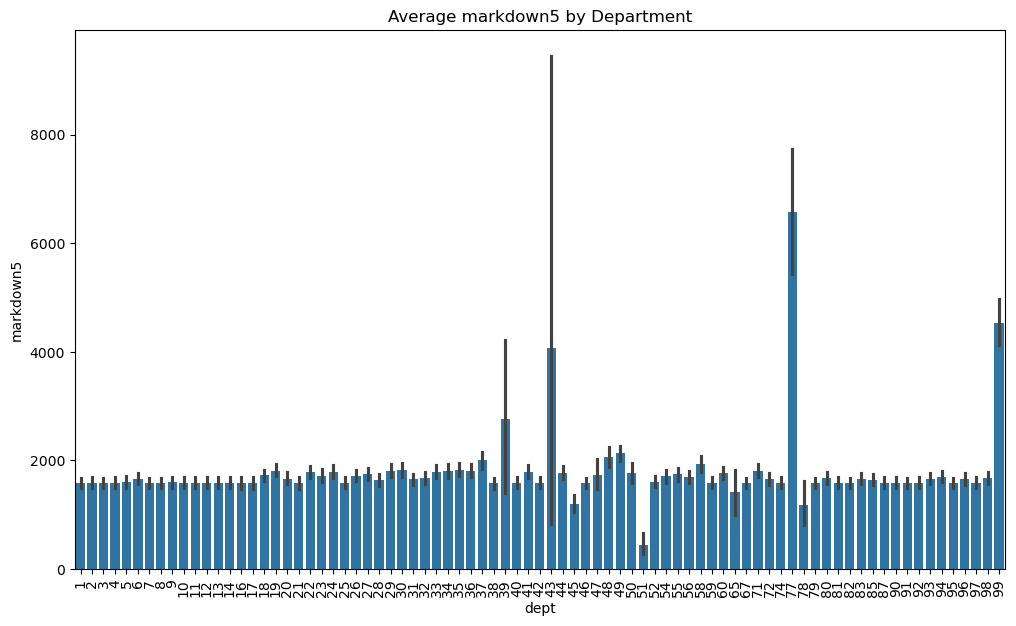

In [33]:
markdowns = retail_df[['markdown1', 'markdown2', 'markdown3', 'markdown4','markdown5',]]
for m in markdowns:
    plt.figure(figsize=(12, 7))
    sns.barplot(data=retail_df, x='dept', y= m)
    plt.title(f"Average {m} by Department")
    plt.xticks(rotation=90)
    plt.show()

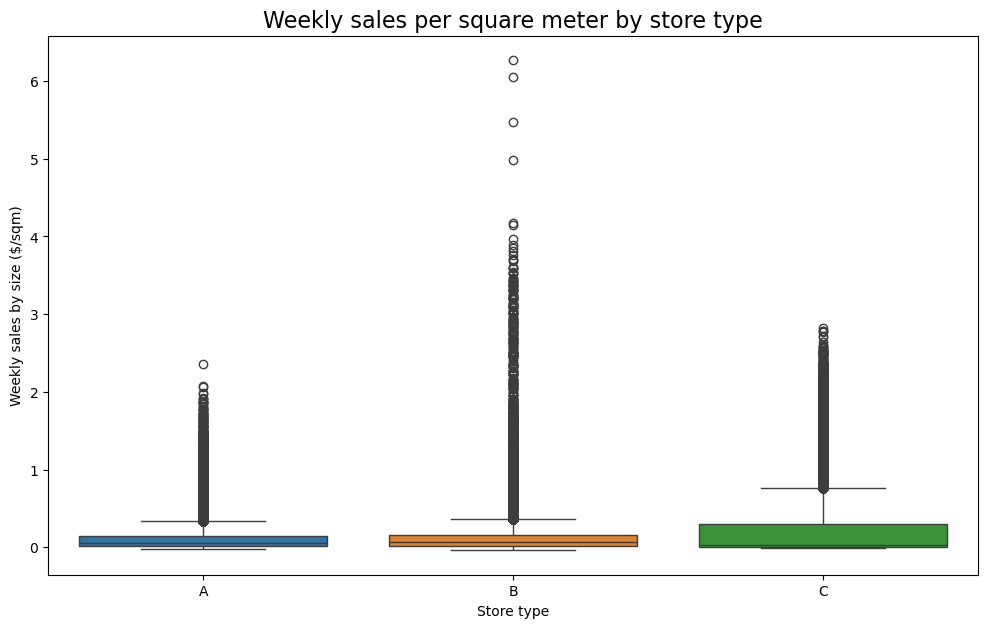

In [34]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=retail_df, x='type', y='weekly_sales_by_size', hue='type')
plt.title('Weekly sales per square meter by store type', fontsize=16)
plt.xlabel('Store type')
plt.ylabel('Weekly sales by size ($/sqm)')
plt.show()


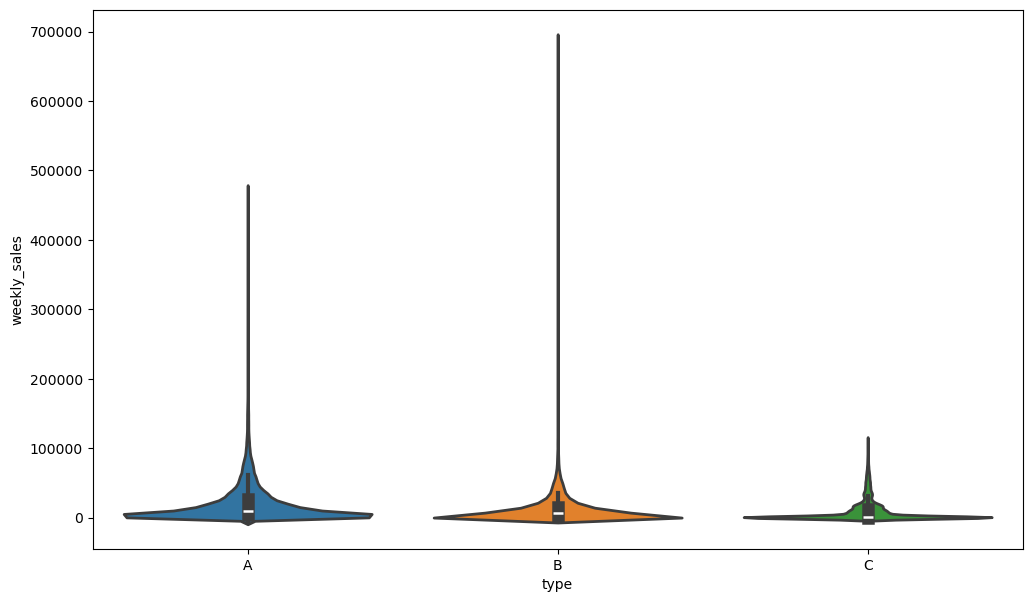

In [35]:
plt.figure(figsize=(12, 7))
sns.violinplot(x='type', y='weekly_sales', data=retail_df, inner="box", linewidth=2, hue='type')
plt.show()

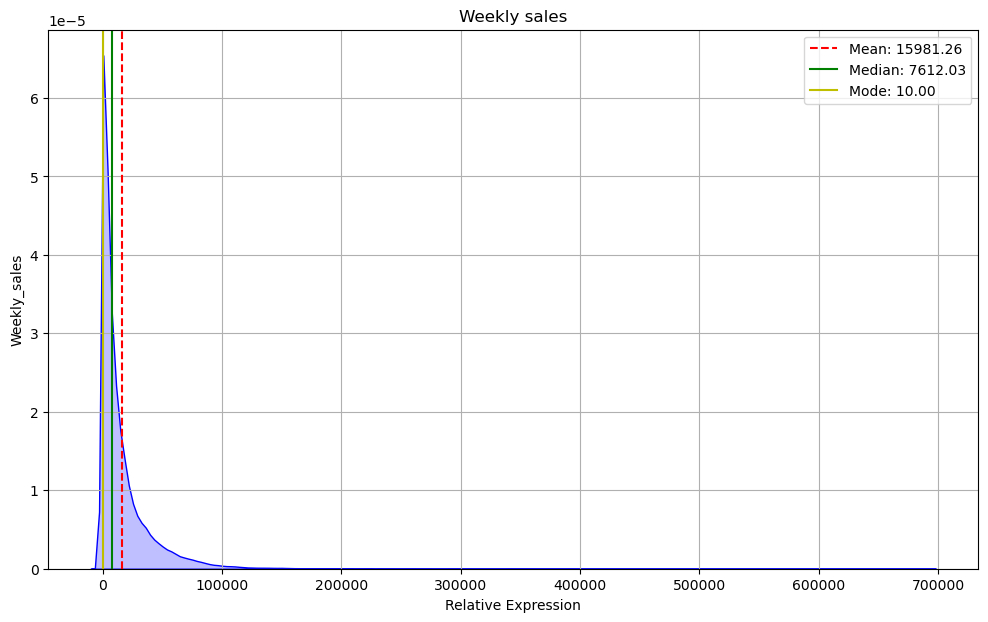

In [36]:
mean = retail_df['weekly_sales'].mean()
mode = retail_df['weekly_sales'].mode()[0]
median = retail_df['weekly_sales'].median()
plt.figure(figsize=(12, 7))
sns.kdeplot(retail_df['weekly_sales'], fill=True, color="b")
plt.axvline(mean, color='r', linestyle='--', label=f'Mean: {mean:.2f}')
plt.axvline(median, color='g', linestyle='-', label=f'Median: {median:.2f}')
plt.axvline(mode, color='y', linestyle='-', label=f'Mode: {mode:.2f}')
plt.title('Weekly sales')
plt.xlabel('Relative Expression')
plt.ylabel('Weekly_sales')
plt.grid(True);plt.legend()
plt.show()

In [37]:
from scipy.stats import shapiro

stat, p = shapiro(retail_df['weekly_sales'].sample(5000))  # sample if very large
print('Shapiro-Wilk test p-value:', p)

Shapiro-Wilk test p-value: 1.4620611718986118e-72


In [38]:
stat, p = shapiro(retail_df['weekly_sales_log'].sample(5000))  # sample if very large
print('Shapiro-Wilk test p-value:', p)

Shapiro-Wilk test p-value: nan


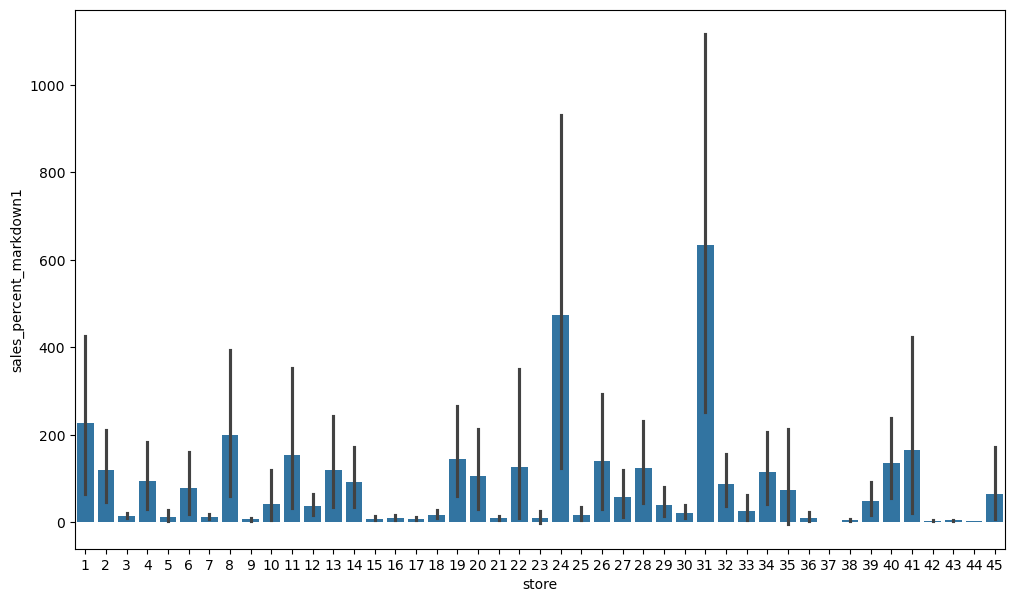

In [39]:
retail_df['sales_percent_markdown1'] = retail_df['markdown1']/retail_df['weekly_sales']
retail_df['sales_percent_markdown2'] = retail_df['markdown2']/retail_df['weekly_sales']
retail_df['sales_percent_markdown3'] = retail_df['markdown3']/retail_df['weekly_sales']
retail_df['sales_percent_markdown4'] = retail_df['markdown4']/retail_df['weekly_sales']
retail_df['sales_percent_markdown5'] = retail_df['markdown5']/retail_df['weekly_sales']

percent_markdowns = [retail_df['sales_percent_markdown1'], retail_df['sales_percent_markdown2'], retail_df['sales_percent_markdown3'], retail_df['sales_percent_markdown4'], retail_df['sales_percent_markdown5']]
plt.figure(figsize= (12, 7))
sns.barplot(data= retail_df, x='store', y='sales_percent_markdown1')
plt.show()

In [ ]:
#All changes on this EDA will be done through Git. 